## **1.importing libreries:**


In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns 
from sklearn.model_selection import train_test_split


In [9]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/most_streamed_spotify_2025.csv")
print("The dataset is loaded, good to go!")

Mounted at /content/drive
The dataset is loaded, good to go!


In [ ]:
df.head()

,rank,track,artist,billed_artist_count,is_collaboration,spotify_streams_total,daily_streams,daily_streams_rank,daily_stream_share_pct,wrapped_global_top10_rank
0,1,Ordinary,Alex Warren,1,False,1948570210,2333502,11,0.1198,4.0
1,2,DtMF,Bad Bunny,1,False,1912497312,3017476,3,0.1578,5.0
2,3,Golden,HUNTR/X,1,False,1759912501,2286960,14,0.1299,7.0
3,4,BAILE INoLVIDABLE,Bad Bunny,1,False,1553054400,2624716,7,0.1690,NaN
4,5,The Fate of Ophelia,Taylor Swift,1,False,1425834222,3046797,2,0.2137,NaN


In [ ]:
print('shape of the dataset:',df.shape)
print('Data type :')
print(df.dtypes)

shape of the dataset: (730, 10)
Data type :
rank                           int64
track                            str
artist                           str
billed_artist_count            int64
is_collaboration                bool
spotify_streams_total          int64
daily_streams                  int64
daily_streams_rank             int64
daily_stream_share_pct       float64
wrapped_global_top10_rank    float64
dtype: object


In [ ]:
print("---Datatypes & non null counts--")
df.info()

---Datatypes & non null counts--
<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rank                       730 non-null    int64  
 1   track                      730 non-null    str    
 2   artist                     730 non-null    str    
 3   billed_artist_count        730 non-null    int64  
 4   is_collaboration           730 non-null    bool   
 5   spotify_streams_total      730 non-null    int64  
 6   daily_streams              730 non-null    int64  
 7   daily_streams_rank         730 non-null    int64  
 8   daily_stream_share_pct     730 non-null    float64
 9   wrapped_global_top10_rank  3 non-null      float64
dtypes: bool(1), float64(2), int64(5), str(2)
memory usage: 52.2 KB


In [ ]:
print("======|symmery of the dataset|=======")
df.describe()

======|symmery of the dataset|=======


,rank,billed_artist_count,spotify_streams_total,daily_streams,daily_streams_rank,daily_stream_share_pct,wrapped_global_top10_rank
count,730.000000,730.000000,7.300000e+02,7.300000e+02,730.000000,730.000000,3.000000
mean,365.500000,1.031507,2.337006e+08,3.684854e+05,365.500000,0.145742,5.333333
std,210.877136,0.174803,2.075011e+08,4.639724e+05,210.877136,0.111047,1.527525
min,1.000000,1.000000,1.002850e+08,9.432000e+03,1.000000,0.008400,4.000000
25%,183.250000,1.000000,1.266382e+08,1.106278e+05,183.250000,0.072875,4.500000
50%,365.500000,1.000000,1.670339e+08,2.229660e+05,365.500000,0.120500,5.000000
75%,547.750000,1.000000,2.456286e+08,4.337102e+05,547.750000,0.182325,6.000000
max,730.000000,2.000000,1.948570e+09,3.075070e+06,730.000000,0.980200,7.000000


In [ ]:
print('Missing value in scah column:')
print(df.isnull().sum())

Missing value in scah column:
rank                           0
track                          0
artist                         0
billed_artist_count            0
is_collaboration               0
spotify_streams_total          0
daily_streams                  0
daily_streams_rank             0
daily_stream_share_pct         0
wrapped_global_top10_rank    727
dtype: int64


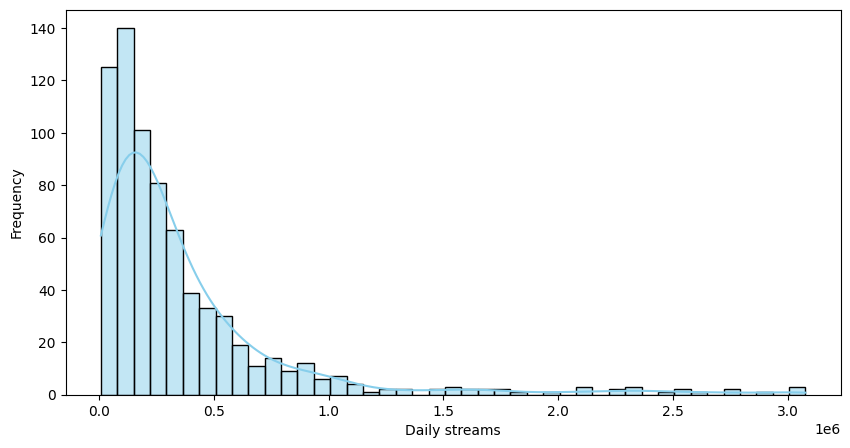

C:\Users\nidhi\AppData\Local\Temp\ipykernel_3224\3546238069.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_collaboration',data=df,palette='Set2')


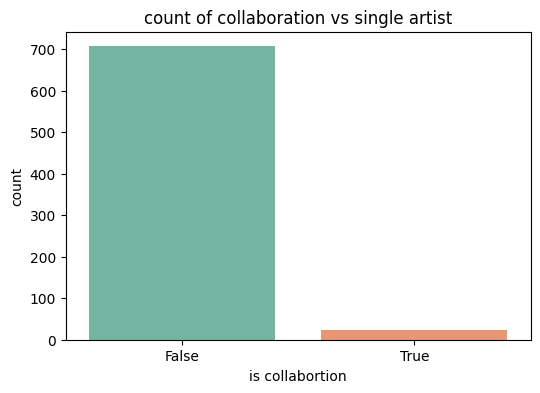

In [ ]:
#visulize distribution for key numeric features 
plt.figure(figsize=(10,5))
sns.histplot(df['daily_streams'],kde=True, color='skyblue')
plt.xlabel('Daily streams')
plt.ylabel('Frequency')
plt.show()

#count plot for collaborations
plt.figure(figsize=(6,4))
sns.countplot(x='is_collaboration',data=df,palette='Set2')
plt.title('count of collaboration vs single artist')
plt.xlabel('is collabortion')
plt.ylabel('count')
plt.show()

**Data Cleaning and Prepration**

In [ ]:
#Handeling missing values 
#For simplicity , we will drop rows with missing values . In production

missing_before = df.isnull().sum()
print('missing values before cleaning ')
print(missing_before)

df=df.dropna()

missing_after=df.isnull().sum()
print('missing values after droping nans')
print(missing_after)
#convert boolean column 'is_collaboration' to integer for modeling
df['is_collaboration']=df['is_collaboration'].astype(int)

missing values before cleaning 
rank                           0
track                          0
artist                         0
billed_artist_count            0
is_collaboration               0
spotify_streams_total          0
daily_streams                  0
daily_streams_rank             0
daily_stream_share_pct         0
wrapped_global_top10_rank    727
dtype: int64
missing values after droping nans
rank                         0
track                        0
artist                       0
billed_artist_count          0
is_collaboration             0
spotify_streams_total        0
daily_streams                0
daily_streams_rank           0
daily_stream_share_pct       0
wrapped_global_top10_rank    0
dtype: int64


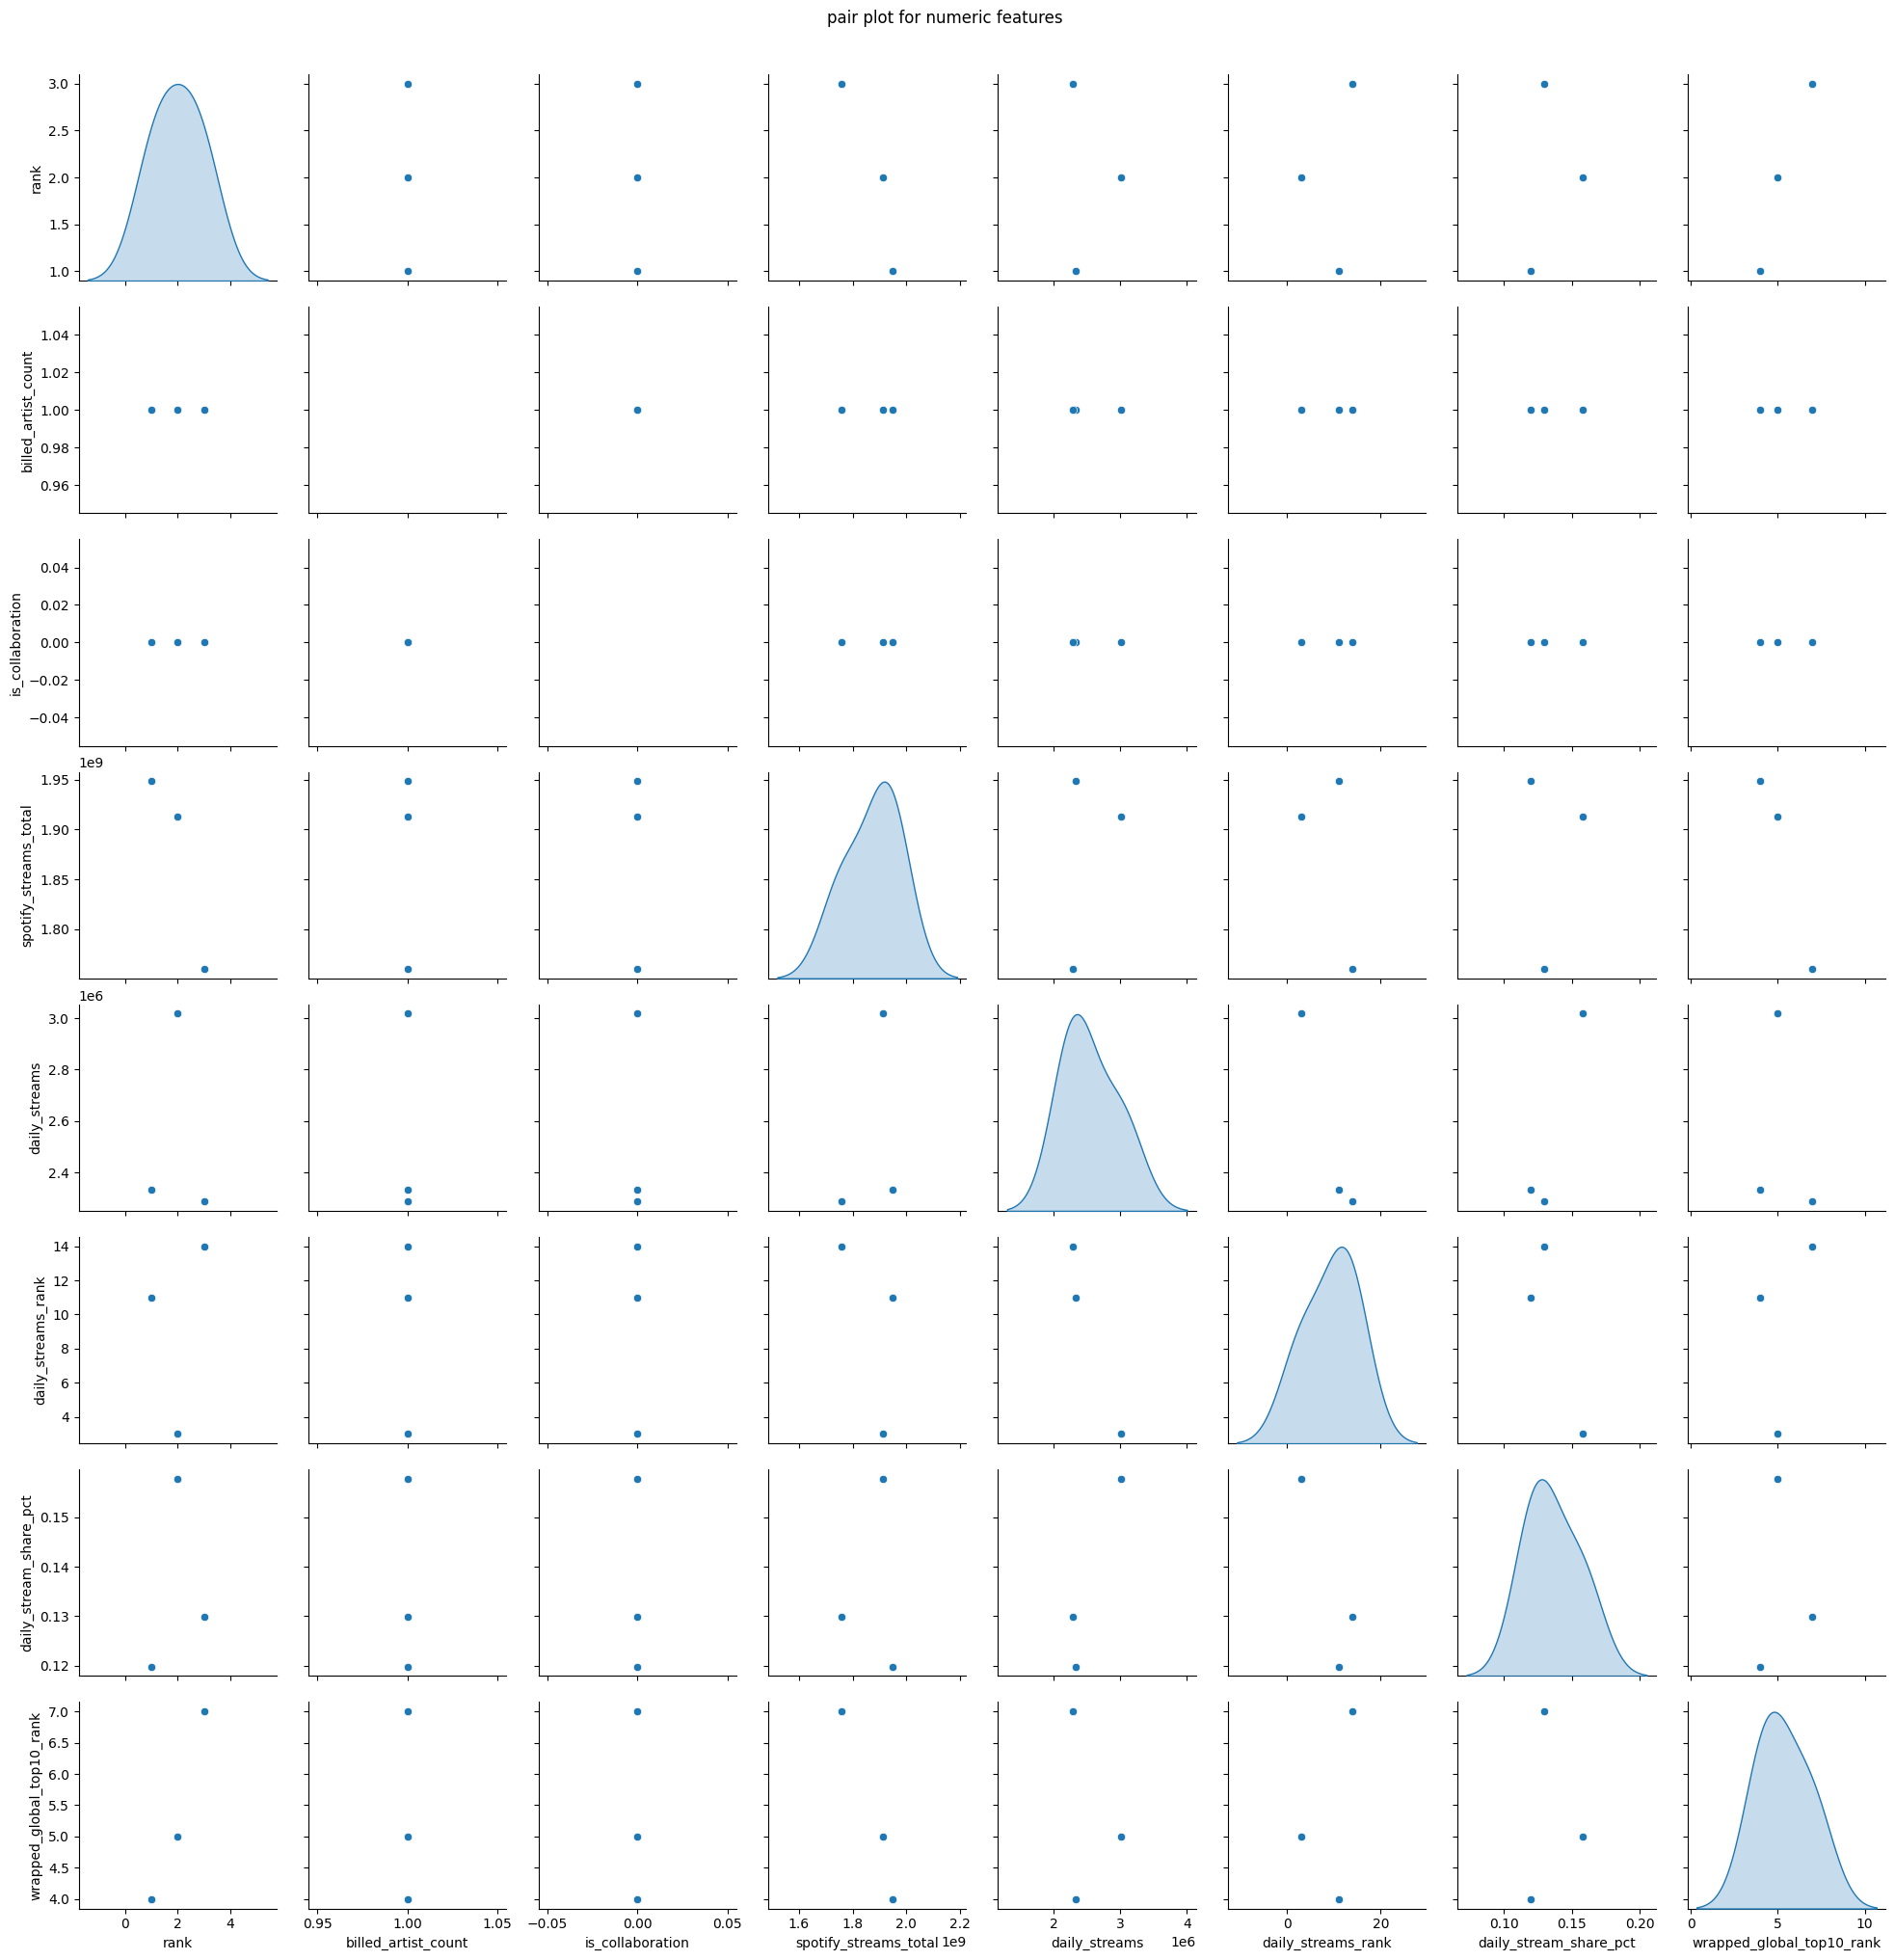

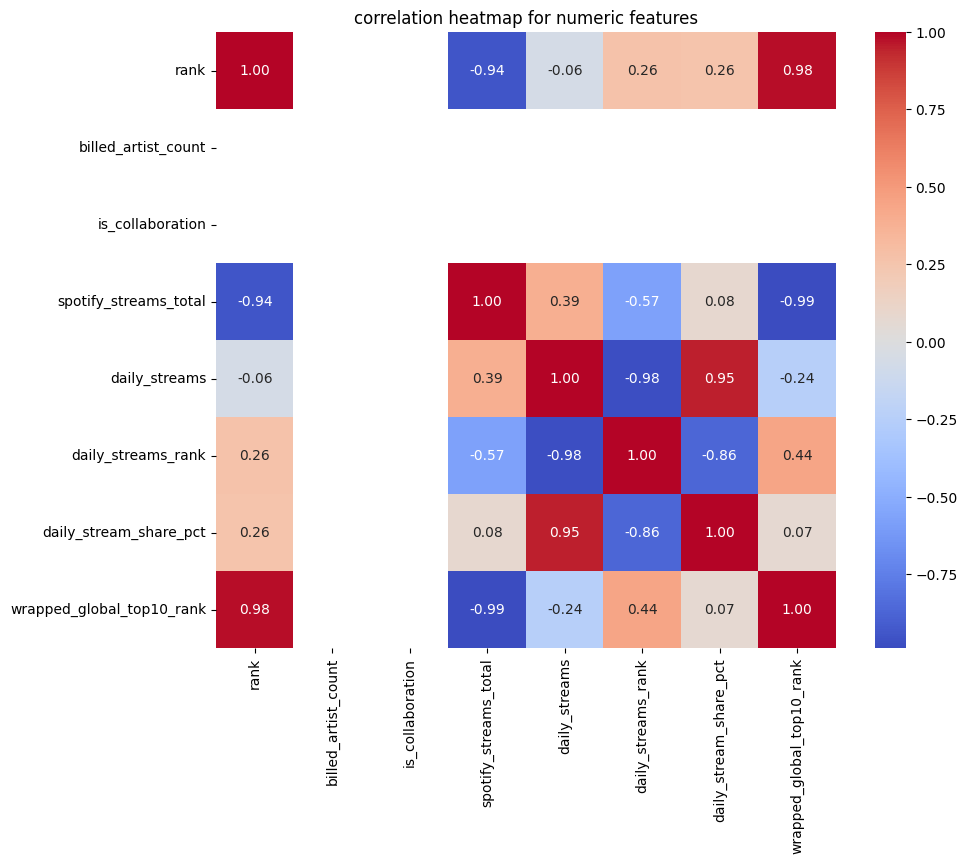

In [ ]:
#Exploratory Data Analysis 
#pair plot for numeric featues if there are four or more numeric columns

numeric_df=df.select_dtypes(include=[np.number]) # selects only numeric columns 
if numeric_df.shape[1] >= 4:
    sns.pairplot(numeric_df, diag_kind='kde')
    plt.suptitle('pair plot for numeric features ',y=1.02)
    plt.show()

#correlations heatmap among numeric features
if numeric_df.shape[1] >=4:
    plt.figure(figsize=(10,8))
    corr_matrix=numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('correlation heatmap for numeric features')
    plt.show()




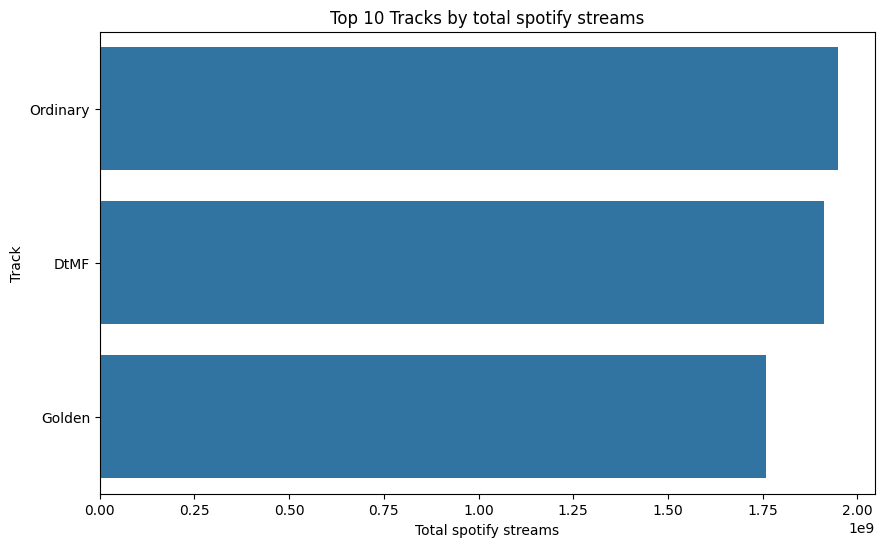

In [ ]:
#bar plot - top 10 tracks by sportify_streams_total
top10=df.sort_values(by='spotify_streams_total', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x='spotify_streams_total',y='track')
plt.title('Top 10 Tracks by total spotify streams')
plt.xlabel('Total spotify streams')
plt.ylabel('Track')
plt.show() 

In [ ]:
x=df.drop[]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split()